Neste notebook estarei prototipando modelos para resolver o problema de classificação da base cifar100 que contém 100 classes através de smoke test, teste de overfitting, teste de holdout, e validação cruzada.
Quando encontrar uma rede neural suficientemente boa, irei treinar ela.

Importação das bibliotecas:

In [1]:
import torch
import torch.nn as nn
from torch import optim
from torchvision import datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms

import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

from skorch.dataset import ValidSplit
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from skorch.callbacks import EarlyStopping, Checkpoint, LRScheduler

Construção do dataset:

In [2]:
torch.manual_seed(123)
transformer = transforms.ToTensor()

train = datasets.CIFAR10(root = '.', train = True, download = True, transform = transformer)
test = datasets.CIFAR10(root = '.', train = False, download = True, transform = transformer)

Parte dos testes pelo skorch:

In [3]:
transformer = transforms.ToTensor()

# Troca a ordem do dataset de NHWC para NCHW o indice 0 permanece em 0, o 3 vai para 1, o 1 vai para 2, e o 2 vai para 3
# Divide por 255 para normalizar
X_train = torch.from_numpy(train.data).float().permute(0, 3, 1, 2) / 255

X_test = torch.from_numpy(test.data).float().permute(0, 3, 1, 2) / 255

y_train = torch.tensor(train.targets, dtype=torch.long)

y_test = torch.tensor(test.targets, dtype = torch.long)


Cada uma das 50000 imagems do dataset tem 3 canais de informações (RGB) contendo imagens de 32 x 32 pixels. Ou seja, cada imagem é como se fosse uma matriz 3D de 3 camadas, com 32 x 32 de width e heigth

Seu dtype é float32

In [4]:
X_train.shape, X_train.dtype

(torch.Size([50000, 3, 32, 32]), torch.float32)

Verifica o tensor y_train para saber se está no formato esperado:

In [5]:
y_train.dtype

torch.int64

Verifica os valores minimos e máximos de y_train, minimo deve ser 0 (Classe 0), e máximo deve ser 9 (Classe 9)

In [6]:
y_train.min(), y_train.max()

(tensor(0), tensor(9))

In [7]:
y_train[3]

tensor(4)

X_train já está normalizado:

In [8]:
X_train[0]

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

Construção do modelo:

In [9]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [10]:
class ClassificadorCIFAR10(nn.Module):
    def __init__(self, dropout_p = 0.3):
        super().__init__()

        # Cria 3 camadas de convolução
        in_channelsList = [3, 32, 64]
        out_channelsList = [32, 64, 128]
        self.convs = nn.ModuleList([nn.Conv2d(in_channels = in_channelsList[i], out_channels = out_channelsList[i], kernel_size = (3, 3), padding = 1) for i in range(3)])

        self.pool = nn.MaxPool2d(kernel_size = (2, 2))  

        # Cria duas camadas de normalização com input de 32 e 64 channels
        bns_channels = [32, 64, 128]
        self.bns = nn.ModuleList([nn.BatchNorm2d(c) for c in bns_channels])

        self.activation = nn.ReLU()

        self.flatten = nn.Flatten()

        # Feito por execução de forward printando self.linear1.in_features
        in_features = 512

        # LazyLinear infere o número de in_features automaticamente
        self.linear1 = nn.LazyLinear(out_features = in_features)
        self.linear2 = nn.LazyLinear(out_features = in_features * 2)

        # 10 classes
        self.output = nn.LazyLinear(out_features = 10)
        self.dropout = nn.Dropout(p = dropout_p)
    
        self.model = nn.Sequential(
            self.convs[0],
            self.bns[0],
            self.activation,
            self.pool,

            self.convs[1],
            self.bns[1],
            self.activation,
            self.pool,

            self.convs[2],
            self.bns[2],
            self.activation,
            self.pool,

            self.flatten,

            self.linear1,
            self.activation,
            self.dropout,

            self.linear2,
            self.activation,
            self.dropout,

            self.output

        )
    
    def forward(self, X):
        return self.model(X)

    def find_out_in_features(self, X):
        self.model(X_train)
        print(self.linear1.in_features)
        return
        

In [11]:
c = ClassificadorCIFAR10()
c.find_out_in_features(X_train[0].unsqueeze(0))

2048


Define a rede prototipo que usara X_small e y_small para testar overfitting e aprendizado

O teste de overfitting é feito para testar se a rede tem a capacidade de se adaptar a um pequeno sample de registors.

Isso é feito pois caso a rede não sofra overfitting com tão poucos registros, certamente existe um problema grande na sua implementação.

Passado o teste de overfitting, pode-se testar outras coisas antes de se dedicar a treinar o modelo por definitivo.

In [12]:
# skorch permite passar parametros para module (O meu objeto classificador), com a sintaxe: module__nomeParametro = valor.
# Por isso passo module__dropout_p = 0.0.
net_small = NeuralNetClassifier(module = ClassificadorCIFAR10,
                                module__dropout_p = 0.0,    
                                criterion = torch.nn.CrossEntropyLoss, 
                                optimizer = optim.Adam,
                                lr = 1e-3,
                                max_epochs = 200,
                                batch_size = 64,
                                iterator_train__shuffle=True,
                                callbacks = [EpochScoring('accuracy', on_train=True, name='train_acc'),],
                                train_split=None,
                                device = device)

Agora pegarei apenas um sample de 200 imagens para verificar se a rede sofre overfitting ou não, e se está aprendendo

In [13]:
X_small = X_train[:200].clone()
y_small = y_train[:200].clone()

Teste de overfitting:

In [14]:
net_small.fit(X_small, y_small)
train_acc = net_small.score(X_small, y_small)

print("train acc small:", train_acc)

if (train_acc >= 0.98):
    print("Sofreu overfitting")

  epoch    train_acc    train_loss     dur
-------  -----------  ------------  ------
      1       0.1000        2.5805  1.2416
      2       0.1900        2.3015  0.0194
      3       0.2450        2.0055  0.0179
      4       0.2550        1.8867  0.0154
      5       0.4000        1.6669  0.0173
      6       0.3600        1.6199  0.0152
      7       0.4400        1.5435  0.0158
      8       0.5250        1.4099  0.0140
      9       0.6000        1.1583  0.0143
     10       0.5350        1.2567  0.0158
     11       0.5650        1.2056  0.0142
     12       0.6850        0.9479  0.0161
     13       0.6450        0.9354  0.0132
     14       0.7350        0.7767  0.0173
     15       0.7900        0.5974  0.0136
     16       0.8300        0.5452  0.0159
     17       0.8700        0.4534  0.0142
     18       0.8850        0.3555  0.0150
     19       0.8600        0.3790  0.0153
     20       0.8550        0.4046  0.0185
     21       0.8850        0.3375  0.0149
     22    

Verifica o historico de acuracias:

In [15]:
acc_history = net_small.history[:, 'train_acc']

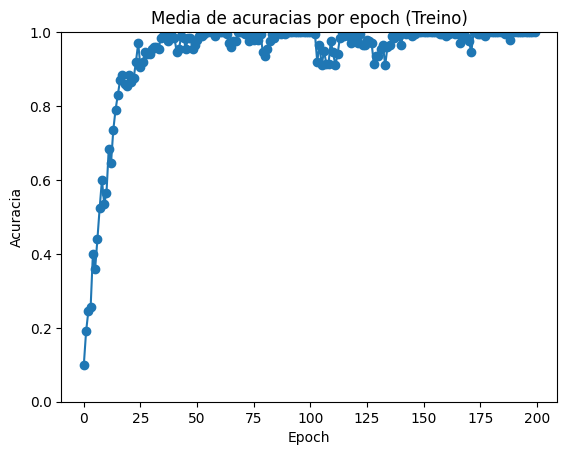

In [16]:
plt.plot(acc_history, marker="o")
plt.title("Media de acuracias por epoch (Treino)")
plt.xlabel("Epoch")
plt.ylabel("Acuracia")
plt.ylim(0, 1)
plt.show()

Smoke test:

Um smoke test é feito testando o aprendizado da rede neural com o dataset real (completo), e usando poucas epochs.

Isso é feito para testar se a rede sai do "acaso" (No caso do cifar 10, acaso seria acertar 10% das classes) aplicando no dataset completo.

In [17]:
net_smoke = NeuralNetClassifier(
    ClassificadorCIFAR10,
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    lr=1e-3,
    max_epochs=3,
    batch_size=128,
    iterator_train__shuffle=True,
    
    # 90% para treino, e 10% para validação
    train_split=ValidSplit(0.1, random_state=42),
    device=device,
)

In [18]:
net_smoke.fit(X_train, y_train)

# última época
print(net_smoke.history[-1])

# pega curva de validação
print("valid_acc por época:", net_smoke.history[:, 'valid_acc'])
print("train_loss por época:", net_smoke.history[:, 'train_loss'])
print("valid_loss por época:", net_smoke.history[:, 'valid_loss'])

  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        1.3928       0.5480        1.2310  64.7339
      2        1.0077       0.6420        0.9900  -54.1268
      3        0.8578       0.7020        0.8478  1.2363
{'batches': [{'train_loss': 0.8239759206771851, 'train_batch_size': 128}, {'train_loss': 0.8404973745346069, 'train_batch_size': 128}, {'train_loss': 0.909201979637146, 'train_batch_size': 128}, {'train_loss': 0.8862003087997437, 'train_batch_size': 128}, {'train_loss': 1.0214605331420898, 'train_batch_size': 128}, {'train_loss': 0.8308688402175903, 'train_batch_size': 128}, {'train_loss': 1.0310750007629395, 'train_batch_size': 128}, {'train_loss': 0.7889201045036316, 'train_batch_size': 128}, {'train_loss': 0.7960665822029114, 'train_batch_size': 128}, {'train_loss': 0.8570492267608643, 'train_batch_size': 128}, {'train_loss': 0.9981480836868286, 'train_batch_size': 128}, {'train_loss': 1.0258873701

Grafico de acuracia da validacao por epoch:

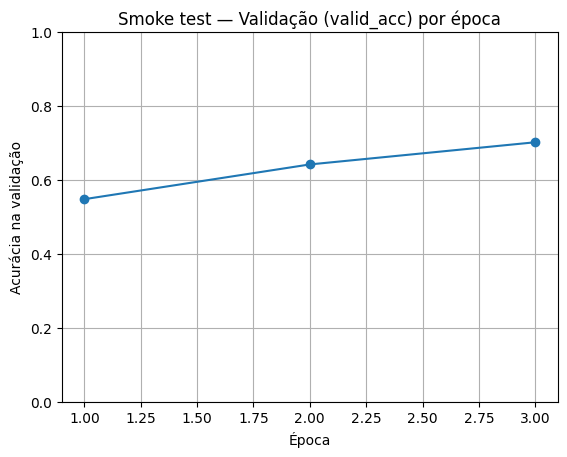

In [19]:
# Pega a lista de valid_acc registrada a cada época
valid_acc = net_smoke.history[:, 'valid_acc']

plt.figure()
plt.plot(range(1, len(valid_acc) + 1), valid_acc, marker='o')
plt.xlabel('Época')
plt.ylabel('Acurácia na validação')
plt.title('Smoke test — Validação (valid_acc) por época')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

Holdout test:

Um holdout test é feito de forma similar a um smoke test,

Separa-se o dataset em treino e validação,
treina-se com o dataset de treino e avalia no de avaliação

Difere-se do smoke test por que aqui são feitas muito mais epochs (Até 50), e usa early stopping e scheduler

# Checkpoint:

Salva o modelo na epoca em que ele tiver a melhor acuracia no dataset de validação.

Ele vai salvando os pesos e biases do modelo a medida em que valid_acc vai melhorando

Pode ocorrer de que o modelo piore de épocas anteriores para posteriores.

Checkpoint faz com que os melhores modelos sejam salvos para evitar terminar com um modelo pior no final do treino.

# Early stopper:

Para o treino se a o indicador "monitor" parar de melhorar por "patience" epochs


# Scheduler:

Reduz o lr automaticamente se o modelo "empaca"

Se o indicador "monitor" parar de melhorar por "patience" epochs, ele reduz o learning_rate.

No começo, um lr alto ajuda a aprender rapido, mas quando chega perto de um bom minimo um lr alto pode ficar "pulando" e estagnar o modelo.

Diminuir o lr dinamicamente nesses pontos é uma das maneiras de resolver isso.

In [20]:
cp = Checkpoint(monitor='valid_loss_best')
es = EarlyStopping(monitor='valid_loss', patience=8, lower_is_better=True)

lr_sched = LRScheduler(
    policy=ReduceLROnPlateau,
    monitor='valid_loss',
    factor=0.5,
    patience=3,
)

In [21]:
net_holdout = NeuralNetClassifier(
    ClassificadorCIFAR10,
    
    criterion=nn.CrossEntropyLoss,
    module__dropout_p=0.4,
    optimizer=optim.Adam,
    lr=1e-3,

    # Adicona uma penalidade para pesos muito grandes forçando a rede a manter pesos menores.
    # Isso ajuda a resolver o overfitting e melhora a generalização,
    # Pois a rede passa a depender menos de pesos especificos.
    optimizer__weight_decay=1e-3,
    
    max_epochs=50,
    batch_size=128,
    iterator_train__shuffle=True,
    train_split=ValidSplit(0.1, random_state=42),  # mesmo split do smoke test
    callbacks=[('cp', cp), ('es', es), ('lr', lr_sched)],
    device=device,
)

In [22]:
net_holdout.fit(X_train, y_train)

# Carrega a rede de volta para o checkpoint
net_holdout.load_params(checkpoint=cp)
best = max(net_holdout.history[:, 'valid_acc'])
print("best valid_acc:", best)
print("última época:", net_holdout.history[-1])

  epoch    train_loss    valid_acc    valid_loss    cp      lr     dur
-------  ------------  -----------  ------------  ----  ------  ------
      1        1.4313       0.5940        1.1232     +  0.0010  1.3602
      2        1.0516       0.6374        1.0232     +  0.0010  1.3071
      3        0.9075       0.7016        0.8800     +  0.0010  1.3052
      4        0.8220       0.6954        0.8595     +  0.0010  1.2647
      5        0.7416       0.7036        0.8147     +  0.0010  1.2479
      6        0.6949       0.7240        0.7861     +  0.0010  1.3570
      7        0.6519       0.7588        0.7072     +  0.0010  1.3229
      8        0.6075       0.7130        0.8412        0.0010  1.2763
      9        0.5665       0.7654        0.6905     +  0.0010  1.2850
     10        0.5331       0.7436        0.7545        0.0010  1.3412
     11        0.5037       0.7692        0.7207        0.0010  1.3167
     12        0.4702       0.7822        0.6387     +  0.0010  1.2627
     1

Plota os graficos de loss e acuracia do treino e validação:

In [23]:
train_loss = net_holdout.history[:, 'train_loss']
valid_loss = net_holdout.history[:, 'valid_loss']
valid_acc  = net_holdout.history[:, 'valid_acc']

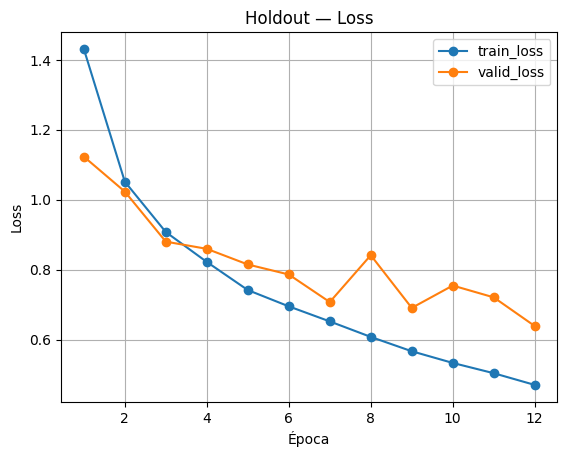

In [24]:
plt.figure()
plt.plot(range(1, len(train_loss)+1), train_loss, marker='o', label='train_loss')
plt.plot(range(1, len(valid_loss)+1), valid_loss, marker='o', label='valid_loss')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Holdout — Loss')
plt.grid(True); plt.legend(); plt.show()

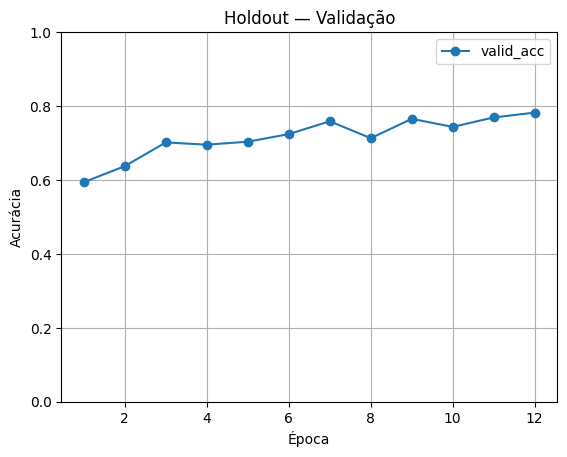

In [25]:
plt.figure()
plt.plot(range(1, len(valid_acc)+1), valid_acc, marker='o', label='valid_acc')
plt.xlabel('Época'); plt.ylabel('Acurácia'); plt.title('Holdout — Validação')
plt.ylim(0, 1); plt.grid(True); plt.legend(); plt.show()

Teste final usando cross validation:

In [26]:
net_cv = NeuralNetClassifier(
    ClassificadorCIFAR10,
    
    criterion=nn.CrossEntropyLoss,
    module__dropout_p=0.4,
    optimizer=optim.Adam,
    lr=1e-3,

    optimizer__weight_decay=1e-3,
    
    max_epochs=15,
    batch_size=128,
    iterator_train__shuffle=True,
    train_split=None,
    device=device,
)

In [27]:
# Garante que cada fold tenha aproximadamente a mesma proporção de classes entre sí e entre o dataset inteiro.
# Serão feitos 5 folds divididos aleatóriamente seguindo a proporção explicada no comentário acima.
cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

In [28]:
scores = cross_val_score(
    net_cv,
    X_train, y_train,
    cv=cv,
    scoring='accuracy',
    # Controla o paralelismo, estou usando a GPU por isso vou manter em 1, para evitar conflitos e desempenho muito pesado.
    n_jobs = 1,
)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.4332  1.0222
      2        1.0763  1.0579
      3        0.9283  1.0631
      4        0.8365  0.9991
      5        0.7683  1.0111
      6        0.7163  1.0161
      7        0.6658  1.1455
      8        0.6222  1.1514
      9        0.5808  1.0417
     10        0.5439  1.0078
     11        0.5075  56.4745
     12        0.4781  -54.4088
     13        0.4436  0.9371
     14        0.4198  0.9480
     15        0.3972  0.9718
  epoch    train_loss     dur
-------  ------------  ------
      1        1.4286  0.9934
      2        1.0494  1.0737
      3        0.9117  0.9754
      4        0.8184  0.9495
      5        0.7665  0.9467
      6        0.7050  56.3902
      7        0.6524  -54.4704
      8        0.6137  0.9940
      9        0.5773  1.0136
     10        0.5373  0.9883
     11        0.5073  56.4566
     12        0.4761  -54.4524
     13        0.4477  1.0041
     14        0.4141  1.0144
 

In [29]:
media = scores.mean()
desvio = scores.std()

In [30]:
media, desvio

(np.float64(0.76658), np.float64(0.012329703970493388))

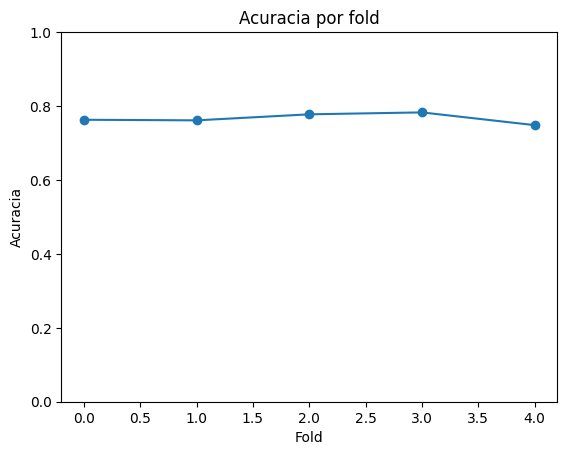

In [31]:
plt.plot(scores, marker="o")
plt.title("Acuracia por fold")
plt.xlabel("Fold")
plt.ylabel("Acuracia")
plt.ylim(0, 1)
plt.show()

A rede neural esta suficientemente boa, agora começarei o seu treinamento:

In [32]:
net_final = NeuralNetClassifier(
    ClassificadorCIFAR10,
    module__dropout_p=0.4,
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    lr=1e-3,
    optimizer__weight_decay=1e-3,
    max_epochs=30,              # escolha baseado no que funcionou no holdout
    batch_size=128,
    iterator_train__shuffle=True,
    train_split=None,           # <<< treino final: usa tudo
    device=device,
)

net_final.fit(X_train, y_train)

  epoch    train_loss     dur
-------  ------------  ------
      1        1.4082  1.2200
      2        1.0403  1.2682
      3        0.8995  1.2824
      4        0.8133  1.2410
      5        0.7454  1.2140
      6        0.6977  1.2271
      7        0.6462  1.3463
      8        0.6036  1.1613
      9        0.5690  1.3128
     10        0.5316  1.5321
     11        0.5050  1.2442
     12        0.4714  1.2950
     13        0.4483  1.1754
     14        0.4272  1.1834
     15        0.3996  1.1720
     16        0.3845  1.1471
     17        0.3611  1.1559
     18        0.3403  1.4084
     19        0.3333  1.3780
     20        0.3220  1.2259
     21        0.3006  1.2627
     22        0.3009  1.2737
     23        0.2832  1.2112
     24        0.2746  1.3567
     25        0.2717  1.3152
     26        0.2632  1.3161
     27        0.2533  0.9232
     28        0.2444  1.2068
     29        0.2453  1.2450
     30        0.2472  1.2264


,module,<class '__mai...cadorCIFAR10'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,None
,classes,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.001
,max_epochs,30
,batch_size,128
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


In [33]:
train_acc = net_final.score(X_train, y_train)
print("TRAIN accuracy:", train_acc)

TRAIN accuracy: 0.94258


Com ela treinada, agora começa o seu teste no dataset de testes:

In [34]:
test_acc = net_final.score(X_test, y_test)
print("TEST accuracy:", test_acc)

TEST accuracy: 0.7742


Mostra aonde o modelo erra (por classe):

In [35]:
y_pred = net_final.predict(X_test)
cm = confusion_matrix(y_test.numpy(), y_pred)

print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test.numpy(), y_pred, digits=4))

Confusion matrix:
 [[711  16 107  30  45  10  14  11  31  25]
 [  9 893   7   9   2   3  10   3   4  60]
 [ 24   2 708  35  73  73  64  11   5   5]
 [  8   5  63 567  55 205  70  18   4   5]
 [  4   0  54  27 787  41  58  26   3   0]
 [  7   2  47  93  40 748  35  26   1   1]
 [  2   2  40  37  22  17 878   1   1   0]
 [  5   2  35  32  86  66   4 764   0   6]
 [ 38  38  23  13  17   4  17   5 812  33]
 [ 19  44   7  15   5  10   9  10   7 874]]

Classification report:
               precision    recall  f1-score   support

           0     0.8597    0.7110    0.7783      1000
           1     0.8894    0.8930    0.8912      1000
           2     0.6489    0.7080    0.6772      1000
           3     0.6608    0.5670    0.6103      1000
           4     0.6952    0.7870    0.7383      1000
           5     0.6355    0.7480    0.6872      1000
           6     0.7575    0.8780    0.8133      1000
           7     0.8731    0.7640    0.8149      1000
           8     0.9355    0.8120    0